<a href="https://colab.research.google.com/github/mariamelfar/Brain-tumor-detection/blob/main/Cancer_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 - Data Preparation


## 0) Import libraries


In [3]:
import os
import json
import random
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
import torchvision

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize

from PIL import Image
import gradio as gr


print("Imports are ready")

Imports are ready


In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## 1) Data Setup

In [5]:
# This an important dataset from Kaggle
import kagglehub
indk214_brain_tumor_dataset_segmentation_and_classification_path = kagglehub.dataset_download('indk214/brain-tumor-dataset-segmentation-and-classification')

print('Data source import complete.')

Using Colab cache for faster access to the 'brain-tumor-dataset-segmentation-and-classification' dataset.
Data source import complete.


In [6]:
train_dir = indk214_brain_tumor_dataset_segmentation_and_classification_path + '/DATASET/classification/Training/'
test_dir  = indk214_brain_tumor_dataset_segmentation_and_classification_path + '/DATASET/classification/Testing/'
classes = ['glioma','meningioma','pituitary','notumor']
RED_IMG_SIZE = 128
seed = 99


print("Data import complete")

Data import complete


## 2) Transformations & augmentations

In [7]:
def generate_dataframe(dir):
    data = {'file_path': [], 'label': []}
    for cls in classes:
        class_dir = os.path.join(dir, cls)
        for f in os.listdir(class_dir):
            data['file_path'].append(os.path.join(class_dir, f))
            data['label'].append(cls)
    df = pd.DataFrame(data)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

print("Labels are ready")

Labels are ready


In [8]:
train_df = generate_dataframe(train_dir)
test_df = generate_dataframe(test_dir)

print("Labels are set on training set and testing set")

Labels are set on training set and testing set


In [9]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.15, contrast=0.15)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("Transformation ready")

Transformation ready


## 3) Train, Val & Test split

In [10]:
full_train_dataset = datasets.ImageFolder(train_dir, transform=val_transform)
class_names = full_train_dataset.classes
num_classes = len(class_names)
print("Class names:", class_names, "Num classes:", num_classes)
print("Total images in TRAIN folder:", len(full_train_dataset))

VAL_RATIO = 0.15
n_total = len(full_train_dataset)
n_val = int(n_total * VAL_RATIO)
n_train = n_total - n_val

train_subset, val_subset = random_split(full_train_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

train_subset.dataset.transform = train_transform
val_subset.dataset.transform = val_transform

test_dataset = datasets.ImageFolder(test_dir, transform=val_transform) if os.path.exists(test_dir) else None
if test_dataset:
    print("Total images in TEST folder:", len(test_dataset))
else:
    print("TEST dataset not found; testing will be skipped.")

BATCH_SIZE = 32
NUM_WORKERS = 2  # adjust for your environment
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS) if test_dataset else None

print("Train size:", len(train_subset), "Val size:", len(val_subset))


Class names: ['glioma', 'meningioma', 'notumor', 'pituitary'] Num classes: 4
Total images in TRAIN folder: 5712
Total images in TEST folder: 1311
Train size: 4856 Val size: 856


# Phase 2 - Exploratory Data Analysis (EDA)

## 0) First look & Summary

In [11]:
print("Train set info:")
print(display(train_df.info()))

Train set info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5712 entries, 0 to 5711
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_path  5712 non-null   object
 1   label      5712 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB


None

None


In [12]:
print("\nTest set info:")
print(display(test_df.info()))


Test set info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_path  1311 non-null   object
 1   label      1311 non-null   object
dtypes: object(2)
memory usage: 20.6+ KB


None

None


## 1) Visualizing

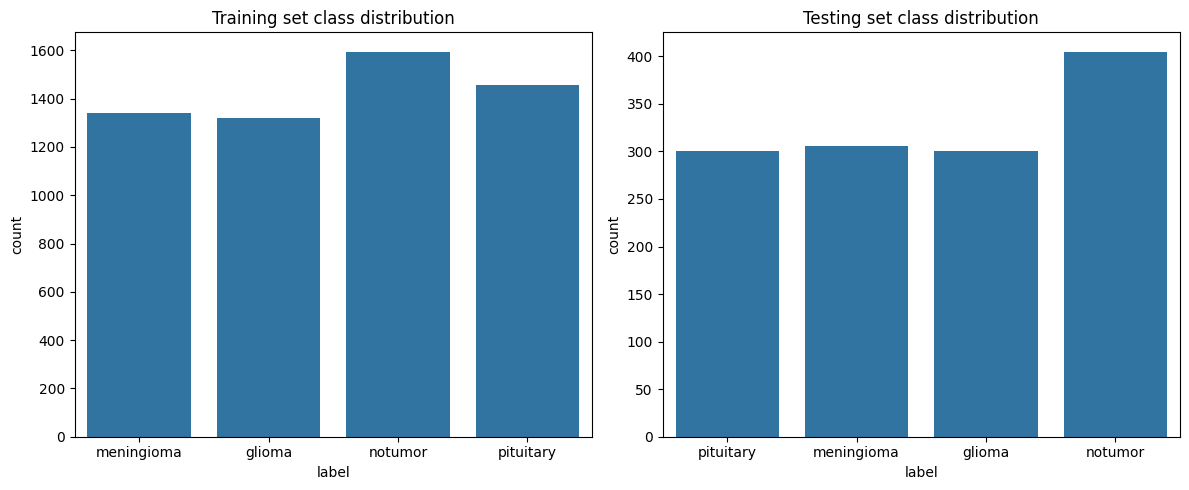

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x='label', data=train_df)
plt.title('Training set class distribution')
plt.subplot(1,2,2)
sns.countplot(x='label', data=test_df)
plt.title('Testing set class distribution')
plt.tight_layout()
plt.show()

## 2) Viewing sample images

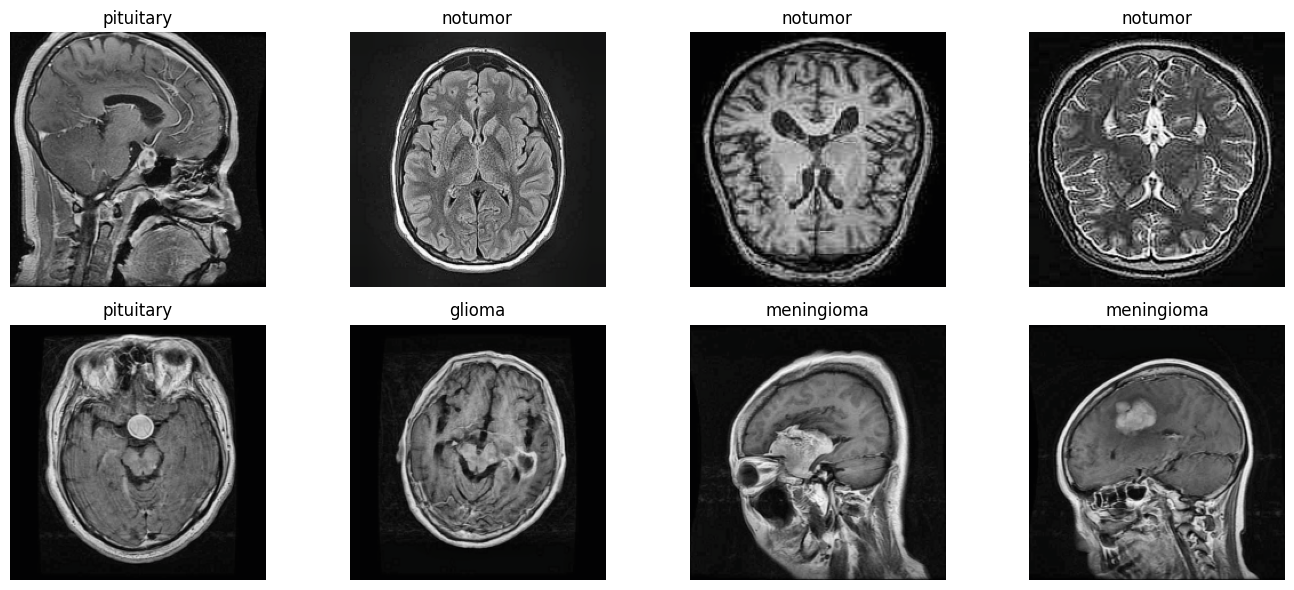

In [14]:
def imshow_tensor2(img_tensor, title=None):
    # unnormalize and show
    img = img_tensor.cpu().numpy().transpose(1,2,0)
    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# take a batch
images, labels = next(iter(train_loader))
n_show = min(8, images.size(0))
plt.figure(figsize=(14,6))
for i in range(n_show):
    plt.subplot(2, 4, i+1)
    imshow_tensor2(images[i], title=class_names[labels[i]])
plt.tight_layout()
plt.show()

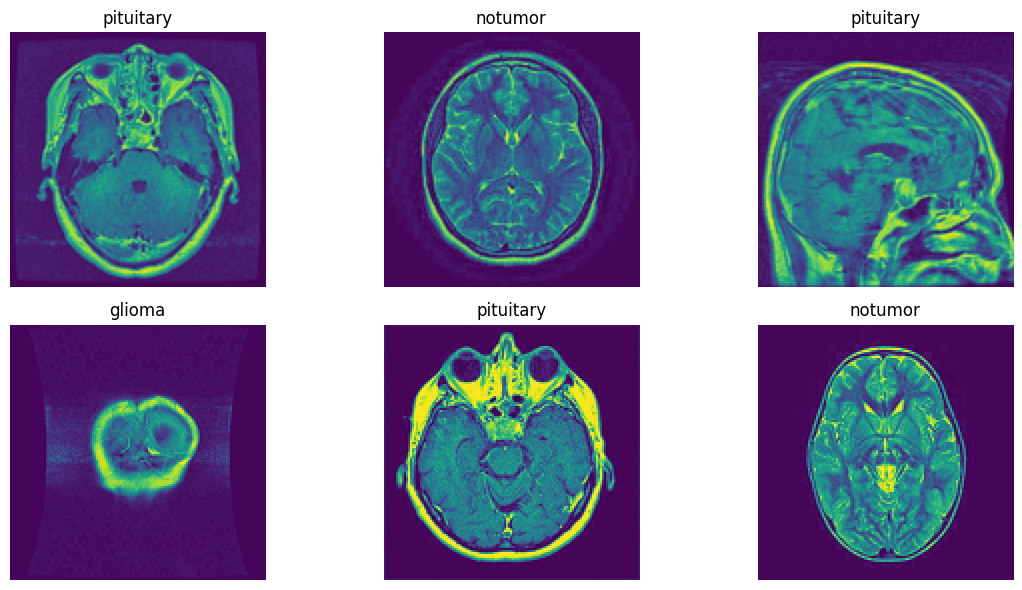

In [15]:
sample_indices = random.sample(range(len(train_df)), 6)
plt.figure(figsize=(12,6))
for i, idx in enumerate(sample_indices):
    img = Image.open(train_df.file_path[idx]).resize((128,128))
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(train_df.label[idx])
    plt.axis('off')
plt.tight_layout()
plt.show()

# Phase 3 - Model Building


## 0) Making backbone (ResNet18)

In [16]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for name, param in model.named_parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(DEVICE)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 1) Loss function, optimizer & class weighting

In [17]:
train_labels = [full_train_dataset.samples[idx][1] for idx in train_subset.indices]
counts = np.bincount(train_labels, minlength=num_classes)
print("Train label counts:", counts)

class_weights = torch.tensor((counts.sum() / (counts + 1e-12)), dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * num_classes  # normalized
print("Class weights (normalized):", class_weights.numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

Train label counts: [1124 1146 1356 1230]
Class weights (normalized): [1.0742487  1.0536261  0.8904539  0.98167115]


# Phase 4 - Model Training & Validation

## 0) Training loop

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        total_samples += images.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples
    return epoch_loss, epoch_acc

print("The Training function is done")

The Training function is done


## 1) Validation Loop

In [19]:

def eval_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    all_preds = []
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels.data).item()
            total_samples += images.size(0)

            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("The Evaluation function is done")

The Evaluation function is done


## 2) Validation & early stopping implementation


In [20]:
EPOCHS, patience = 12, 3
best_val_loss, patience_counter, best_model_wts = float("inf"), 0, None
history = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc"]}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, *_ = eval_model(model, val_loader, criterion, DEVICE)

    for k, v in zip(history.keys(), [train_loss, train_acc, val_loss, val_acc]): history[k].append(v)
    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{EPOCHS} "
          f"- Train: loss {train_loss:.4f}, acc {train_acc*100:.2f}% "
          f"- Val: loss {val_loss:.4f}, acc {val_acc*100:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss, best_model_wts, patience_counter = val_loss, model.state_dict(), 0
        print("New best model saved")
    elif (patience_counter := patience_counter + 1) >= patience:
        print("Early stopping triggered"); break

if best_model_wts:
    model.load_state_dict(best_model_wts)
    print("Best model loaded")
else:
    print("No best model was saved")


Epoch 1/12 - Train: loss 0.7089, acc 76.15% - Val: loss 0.4156, acc 87.62%
New best model saved
Epoch 2/12 - Train: loss 0.4256, acc 85.75% - Val: loss 0.3256, acc 90.65%
New best model saved
Epoch 3/12 - Train: loss 0.3650, acc 87.91% - Val: loss 0.3198, acc 89.60%
New best model saved
Epoch 4/12 - Train: loss 0.3361, acc 88.32% - Val: loss 0.2995, acc 90.07%
New best model saved
Epoch 5/12 - Train: loss 0.3310, acc 88.59% - Val: loss 0.2622, acc 90.77%
New best model saved
Epoch 6/12 - Train: loss 0.3020, acc 89.29% - Val: loss 0.2585, acc 92.06%
New best model saved
Epoch 7/12 - Train: loss 0.2948, acc 89.81% - Val: loss 0.2499, acc 92.52%
New best model saved
Epoch 8/12 - Train: loss 0.2749, acc 90.26% - Val: loss 0.2293, acc 92.17%
New best model saved
Epoch 9/12 - Train: loss 0.2805, acc 90.05% - Val: loss 0.2330, acc 91.59%
Epoch 10/12 - Train: loss 0.2730, acc 90.12% - Val: loss 0.2193, acc 92.64%
New best model saved
Epoch 11/12 - Train: loss 0.2517, acc 91.12% - Val: loss 0.2

# Phase 5 - Evaluation

## 0) Classification report (multiclass)

In [21]:
if test_loader is None:
    print("No test set available; using validation set for evaluation.")
    eval_loader = val_loader
else:
    eval_loader = test_loader

val_loss, val_acc, y_true, y_pred, y_probs = eval_model(model, eval_loader, criterion, DEVICE)

print("Multiclass classification report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
print("Accuracy:", accuracy_score(y_true, y_pred))


Multiclass classification report:
              precision    recall  f1-score   support

      glioma       0.90      0.86      0.88       300
  meningioma       0.77      0.75      0.76       306
     notumor       0.90      1.00      0.95       405
   pituitary       0.94      0.89      0.92       300

    accuracy                           0.88      1311
   macro avg       0.88      0.87      0.88      1311
weighted avg       0.88      0.88      0.88      1311

Accuracy: 0.881769641495042


## 1) Binary tumor vs no tumor metrics

In [22]:
no_tumor_names = ["notumor", "no_tumor", "no-tumor", "healthy", "normal"]
no_tumor_idx = None
for i, cname in enumerate(class_names):
    if cname.lower() in no_tumor_names:
        no_tumor_idx = i
        break

if no_tumor_idx is None:
    no_tumor_idx = num_classes - 1
    print("No explicit 'notumor' name found; using last class index as no_tumor_idx:", no_tumor_idx, class_names[no_tumor_idx])
else:
    print("Detected no_tumor class at index:", no_tumor_idx, class_names[no_tumor_idx])

binary_true = (y_true != no_tumor_idx).astype(int)
prob_no_tumor = y_probs[:, no_tumor_idx]
prob_tumor = 1.0 - prob_no_tumor
binary_pred = (prob_tumor >= 0.5).astype(int)

acc_bin = accuracy_score(binary_true, binary_pred)
prec_bin = precision_score(binary_true, binary_pred, zero_division=0)
rec_bin = recall_score(binary_true, binary_pred, zero_division=0)
f1_bin = f1_score(binary_true, binary_pred, zero_division=0)
try:
    roc_auc_bin = roc_auc_score(binary_true, prob_tumor)
except Exception:
    roc_auc_bin = None

print(f"Binary (Tumor vs NoTumor) metrics — Accuracy: {acc_bin:.4f}, Precision: {prec_bin:.4f}, Recall: {rec_bin:.4f}, F1: {f1_bin:.4f}, ROC-AUC: {roc_auc_bin}")


Detected no_tumor class at index: 2 notumor
Binary (Tumor vs NoTumor) metrics — Accuracy: 0.9641, Precision: 0.9942, Recall: 0.9536, F1: 0.9735, ROC-AUC: 0.9970920884092334


## 2) Example predictions on a few images from eval_loader

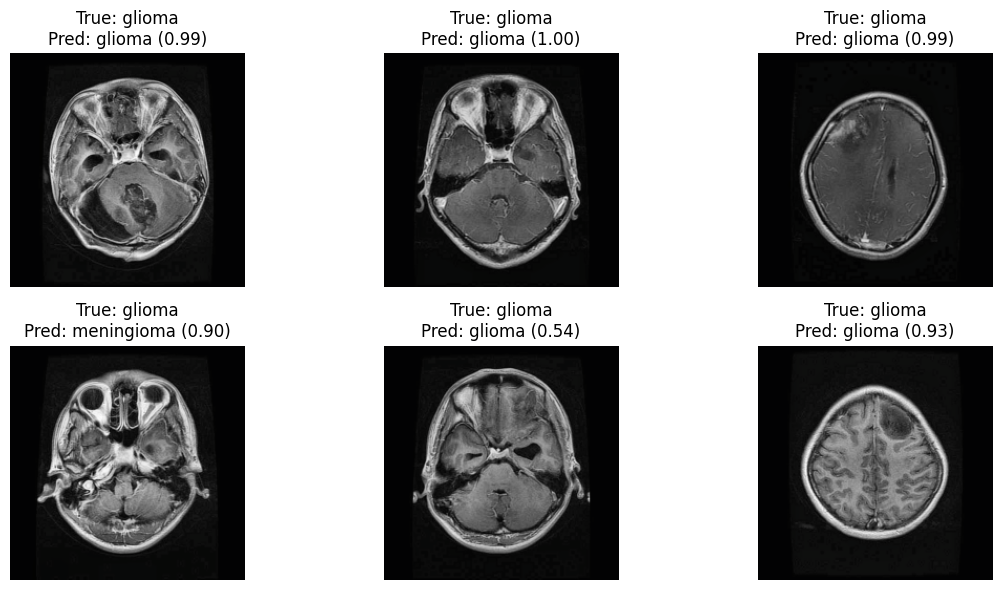

In [23]:
model.eval()
examples = []
with torch.no_grad():
    for images, labels in eval_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        for i in range(min(6, images.size(0))):
            examples.append((images[i].cpu(), labels[i].cpu().item(), preds[i].cpu().item(), probs[i].cpu().numpy()))
        break

plt.figure(figsize=(12,6))
for i, (img_tensor, true_label, pred_label, prob_arr) in enumerate(examples):
    plt.subplot(2, 3, i+1)

    img = img_tensor.numpy().transpose(1,2,0)
    mean = np.array([0.485,0.456,0.406]); std = np.array([0.229,0.224,0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]} ({prob_arr[pred_label]:.2f})"
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Phase 6: Deployment

## 1) Save label map & prediction helper

In [24]:
LABEL_MAP_PATH = os.path.join("/content/", "label_map.json")
label_map = {i: name for i, name in enumerate(class_names)}
with open(LABEL_MAP_PATH, "w") as f:
    json.dump(label_map, f)
print("Saved label map to", LABEL_MAP_PATH)

# Prediction helper function
from PIL import Image

def predict_image(model, image, transform=val_transform, device=DEVICE):
    model.eval()
    if isinstance(image, str):
        image = Image.open(image).convert("RGB")
    elif not isinstance(image, Image.Image):
        raise ValueError("image must be a PIL.Image or path string")

    input_t = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(input_t)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        pred_idx = int(probs.argmax())
    return pred_idx, label_map[pred_idx], probs

Saved label map to /content/label_map.json


In [25]:
torch.save(model.state_dict(), "brain_tumor_model.pth")
print("Model saved as brain_tumor_model.pth")

Model saved as brain_tumor_model.pth


# Phase 7 – Deployment with gradio



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18()
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)  # Change to 4 output classes
model.load_state_dict(torch.load("brain_tumor_model.pth", map_location=device))
model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# The Gradio interface will output probabilities for the original 4 classes
classes = ["glioma","meningioma","pituitary","notumor"]

def predict(image):
    image = image.convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = nn.Softmax(dim=1)(outputs)
        # Return a dictionary mapping class names to probabilities
        return {classes[i]: float(probs[0][i]) for i in range(len(classes))}

# Gradio interface
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=2),
    title="🧠 Brain Tumor Detection",
    description="Upload an MRI/CT scan to detect brain tumor presence."
)

interface.launch(share=True)

NameError: name 'torch' is not defined

In [27]:
# Detailed Gradio app: show top-k predictions with probabilities
def gradio_predict_detailed(img):
    model = load_model_for_inference("best_model.pth", device=device)
    pred_class, probs = predict_image(model, img, label_map=LABEL_MAP, device=device, topk=3)
    return {cls: float(p) for cls, p in probs.items()}

iface_detailed = gr.Interface(
    fn=gradio_predict_detailed,
    inputs=gr.Image(type="filepath"),
    outputs="label",
    title="Brain Tumor Classification (Detailed)",
    description="Upload a brain scan image to see top-k predicted tumor types with probabilities."
)

iface_detailed.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://541e2630f4a0779850.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
